In [ ]:
from a_NN_Samplers_and_VI_algo import RatioNet, train_ratio_net
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from a_NN_Samplers_and_VI_algo import (
    Losses_BANAN,
    RiemannianMetric,
    Brownian_sampler,
    MMD_loss_biased,
)

torch.set_default_dtype(torch.float64)

In [ ]:


DIM = 2
N_SAMPLES = 200          # points per cloud
WALK_LEN = 50           # Brownian steps
STEP_SIZE = 0.01
N_OPT_STEPS_KL = 200

MU_START_KL = torch.tensor([1.0, 1.0])  
LR_KL = 5e-2
RATIO_NET_STEPS = 10      # inner training steps for the discriminator per outer iter
RATIO_NET_LR = 1e-3
SEED_KL = 0

loss_fn = Losses_BANAN()
metric = RiemannianMetric(loss_fn)


torch.manual_seed(SEED_KL)
np.random.seed(SEED_KL)

sampler_kl = Brownian_sampler(
    metric=metric,
    walk_len=WALK_LEN,
    step_size=STEP_SIZE,
    n_samples=N_SAMPLES,
)

mu = torch.nn.Parameter(MU_START_KL.clone().to(dtype=torch.float64))
opt_mu = torch.optim.Adam([mu], lr=LR_KL)

ratio_net = RatioNet(DIM).to(dtype=torch.float64)

mu_hist_kl  = [mu.detach().cpu().numpy().copy()]
kl_hist     = []
acc_hist    = []   # discriminator accuracy — diagnostic of separability

for k in range(N_OPT_STEPS_KL):
    # 1) Train the discriminator on detached samples.
    X_q_det = sampler_kl.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
    X_p_det = sampler_kl.sample_prior(mu.dtype, mu.device, DIM)
    train_ratio_net(ratio_net, X_q_det, X_p_det,
                    n_steps=RATIO_NET_STEPS, lr=RATIO_NET_LR)

    # diagnostic: how easily can the classifier tell q from p?
    with torch.no_grad():
        lq = ratio_net(X_q_det)
        lp = ratio_net(X_p_det)
        acc = ((lq > 0).double().mean() + (lp < 0).double().mean()) / 2
        acc_hist.append(acc.item())

    # 2) Freeze discriminator, update mu.
    for p in ratio_net.parameters():
        p.requires_grad_(False)

    X_q = sampler_kl.sample_q_endpoints(mu, detach_from_mu=False, drift=False)
    kl_term = ratio_net(X_q).mean()        # KL(q || p) ≈ E_q[log q/p]

    opt_mu.zero_grad()
    kl_term.backward()
    opt_mu.step()

    for p in ratio_net.parameters():
        p.requires_grad_(True)

    kl_hist.append(kl_term.item())
    mu_hist_kl.append(mu.detach().cpu().numpy().copy())

    if (k + 1) % 20 == 0:
        print(f"iter {k+1:4d} | KL≈{kl_term.item():+.4f} | "
              f"disc_acc={acc.item():.3f} | "
              f"mu={mu.detach().cpu().numpy()}")

mu_hist_kl = np.array(mu_hist_kl)

# Final clouds for plotting
with torch.no_grad():
    torch.manual_seed(SEED_KL + 999)
    X_q_final_kl = sampler_kl.sample_q_endpoints(mu, detach_from_mu=True, drift=False).cpu().numpy()
    X_p_final_kl = sampler_kl.sample_prior(mu.dtype, mu.device, DIM).cpu().numpy()

iter   20 | KL≈+0.3235 | disc_acc=0.693 | mu=[0.10230539 0.10927919]
iter   40 | KL≈+0.3288 | disc_acc=0.695 | mu=[-0.11396708 -0.12404736]
iter   60 | KL≈+0.3453 | disc_acc=0.705 | mu=[ 0.04166768 -0.01994506]
iter   80 | KL≈+0.4295 | disc_acc=0.725 | mu=[-0.02714259  0.02785364]
iter  100 | KL≈+0.6262 | disc_acc=0.705 | mu=[0.03619583 0.01973994]
iter  120 | KL≈+0.4276 | disc_acc=0.710 | mu=[-0.00779804 -0.03508143]
iter  140 | KL≈+0.5087 | disc_acc=0.720 | mu=[0.02340589 0.00374552]
iter  160 | KL≈+0.4485 | disc_acc=0.672 | mu=[ 0.04006375 -0.024823  ]
iter  180 | KL≈+0.5362 | disc_acc=0.712 | mu=[0.00340063 0.00075965]
iter  200 | KL≈+0.4016 | disc_acc=0.718 | mu=[-0.02358023  0.0076182 ]


In [3]:
gx = np.linspace(-7.0, 7.0, 300)
gy = np.linspace(-7.0, 7.0, 300)
GX, GY = np.meshgrid(gx, gy)
LOSS = (GX * GY - 1.0) ** 2
LOG_LOSS = np.log10(LOSS + 1e-3)

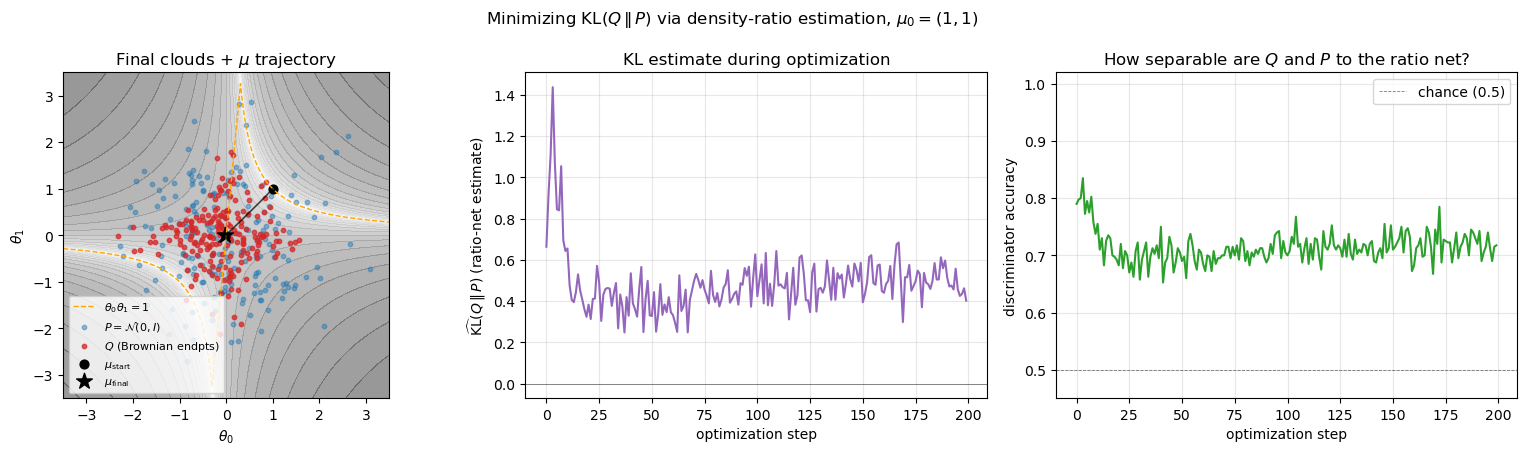

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Panel 1: final clouds + mu trajectory on the loss landscape
ax = axes[0]
ax.contourf(GX, GY, LOG_LOSS, levels=25, cmap="Greys", alpha=0.55)
xs = np.linspace(-3.5, 3.5, 400)
xs_nz = xs[np.abs(xs) > 0.3]
ax.plot(xs_nz, 1.0 / xs_nz, color="orange", lw=1.0, ls="--", label=r"$\theta_0\theta_1=1$")
ax.scatter(X_p_final_kl[:, 0], X_p_final_kl[:, 1], s=10, alpha=0.45,
           color="tab:blue", label=r"$P=\mathcal{N}(0,I)$")
ax.scatter(X_q_final_kl[:, 0], X_q_final_kl[:, 1], s=10, alpha=0.75,
           color="tab:red", label=r"$Q$ (Brownian endpts)")
ax.plot(mu_hist_kl[:, 0], mu_hist_kl[:, 1], color="black", lw=1.2, alpha=0.7)
ax.scatter([mu_hist_kl[0, 0]], [mu_hist_kl[0, 1]], color="black", marker="o", s=40,
           label=r"$\mu_{\mathrm{start}}$")
ax.scatter([mu_hist_kl[-1, 0]], [mu_hist_kl[-1, 1]], color="black", marker="*", s=140,
           label=r"$\mu_{\mathrm{final}}$")
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5); ax.set_aspect("equal")
ax.set_xlabel(r"$\theta_0$"); ax.set_ylabel(r"$\theta_1$")
ax.set_title("Final clouds + $\\mu$ trajectory")
ax.legend(loc="lower left", fontsize=8)

# Panel 2: KL estimate over iterations
ax = axes[1]
ax.plot(kl_hist, color="tab:purple")
ax.axhline(0, color="k", lw=0.6, alpha=0.5)
ax.set_xlabel("optimization step")
ax.set_ylabel(r"$\widehat{\mathrm{KL}}(Q \,\|\, P)$ (ratio-net estimate)")
ax.set_title("KL estimate during optimization")
ax.grid(True, alpha=0.3)

# Panel 3: discriminator accuracy
ax = axes[2]
ax.plot(acc_hist, color="tab:green")
ax.axhline(0.5, color="k", lw=0.6, ls="--", alpha=0.5, label="chance (0.5)")
ax.set_xlabel("optimization step")
ax.set_ylabel("discriminator accuracy")
ax.set_title("How separable are $Q$ and $P$ to the ratio net?")
ax.set_ylim(0.45, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(r"Minimizing $\mathrm{KL}(Q \,\|\, P)$ via density-ratio estimation, $\mu_0=(1,1)$",
             fontsize=12)
fig.tight_layout()
plt.show()

In [5]:


# --- config ---
MU_START_SNAP_KL = torch.tensor([1.0, 1.0])
N_OPT_STEPS_SNAP_KL = 200
SNAP_STEPS_KL = [0, 10, 25, 50, 100, 200]
RATIO_NET_STEPS = 100
RATIO_NET_LR = 1e-3
LR_KL = 5e-2
SEED_KL = 0

torch.manual_seed(SEED_KL)
np.random.seed(SEED_KL)

sampler_snap_kl = Brownian_sampler(
    metric=metric,
    walk_len=WALK_LEN,
    step_size=STEP_SIZE,
    n_samples=N_SAMPLES,
)

mu = torch.nn.Parameter(MU_START_SNAP_KL.clone().to(dtype=torch.float64))
opt_mu = torch.optim.Adam([mu], lr=LR_KL)
ratio_net = RatioNet(DIM).to(dtype=torch.float64)

snapshots_kl = {}
mu_hist_snap_kl = [mu.detach().cpu().numpy().copy()]
kl_hist_snap = []
acc_hist_snap = []

def take_snapshot_kl(it):
    with torch.no_grad():
        torch.manual_seed(SEED_KL + 1000 + it)
        Xq = sampler_snap_kl.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
        Xp = sampler_snap_kl.sample_prior(mu.dtype, mu.device, DIM)
        kl_est = ratio_net(Xq).mean().item()
        lq = ratio_net(Xq); lp = ratio_net(Xp)
        acc = ((lq > 0).double().mean() + (lp < 0).double().mean()).item() / 2
    snapshots_kl[it] = {
        "mu": mu.detach().cpu().numpy().copy(),
        "X_q": Xq.cpu().numpy(),
        "X_p": Xp.cpu().numpy(),
        "kl": kl_est,
        "acc": acc,
    }

# snapshot at iter 0 (before any update)
# train ratio net once first so the iter-0 KL estimate is meaningful
X_q_det = sampler_snap_kl.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
X_p_det = sampler_snap_kl.sample_prior(mu.dtype, mu.device, DIM)
train_ratio_net(ratio_net, X_q_det, X_p_det,
                n_steps=RATIO_NET_STEPS, lr=RATIO_NET_LR)
take_snapshot_kl(0)

for k in range(1, N_OPT_STEPS_SNAP_KL + 1):
    # 1) train discriminator on detached samples
    X_q_det = sampler_snap_kl.sample_q_endpoints(mu, detach_from_mu=True, drift=False)
    X_p_det = sampler_snap_kl.sample_prior(mu.dtype, mu.device, DIM)
    train_ratio_net(ratio_net, X_q_det, X_p_det,
                    n_steps=RATIO_NET_STEPS, lr=RATIO_NET_LR)

    with torch.no_grad():
        lq = ratio_net(X_q_det); lp = ratio_net(X_p_det)
        acc = ((lq > 0).double().mean() + (lp < 0).double().mean()).item() / 2
        acc_hist_snap.append(acc)

    # 2) freeze discriminator, update mu
    for p in ratio_net.parameters():
        p.requires_grad_(False)

    X_q = sampler_snap_kl.sample_q_endpoints(mu, detach_from_mu=False, drift=False)
    kl_term = ratio_net(X_q).mean()

    opt_mu.zero_grad()
    kl_term.backward()
    opt_mu.step()

    for p in ratio_net.parameters():
        p.requires_grad_(True)

    kl_hist_snap.append(kl_term.item())
    mu_hist_snap_kl.append(mu.detach().cpu().numpy().copy())

    if k in SNAP_STEPS_KL:
        take_snapshot_kl(k)

mu_hist_snap_kl = np.array(mu_hist_snap_kl)
print("snapshots taken at iters:", sorted(snapshots_kl.keys()))

snapshots taken at iters: [0, 10, 25, 50, 100, 200]


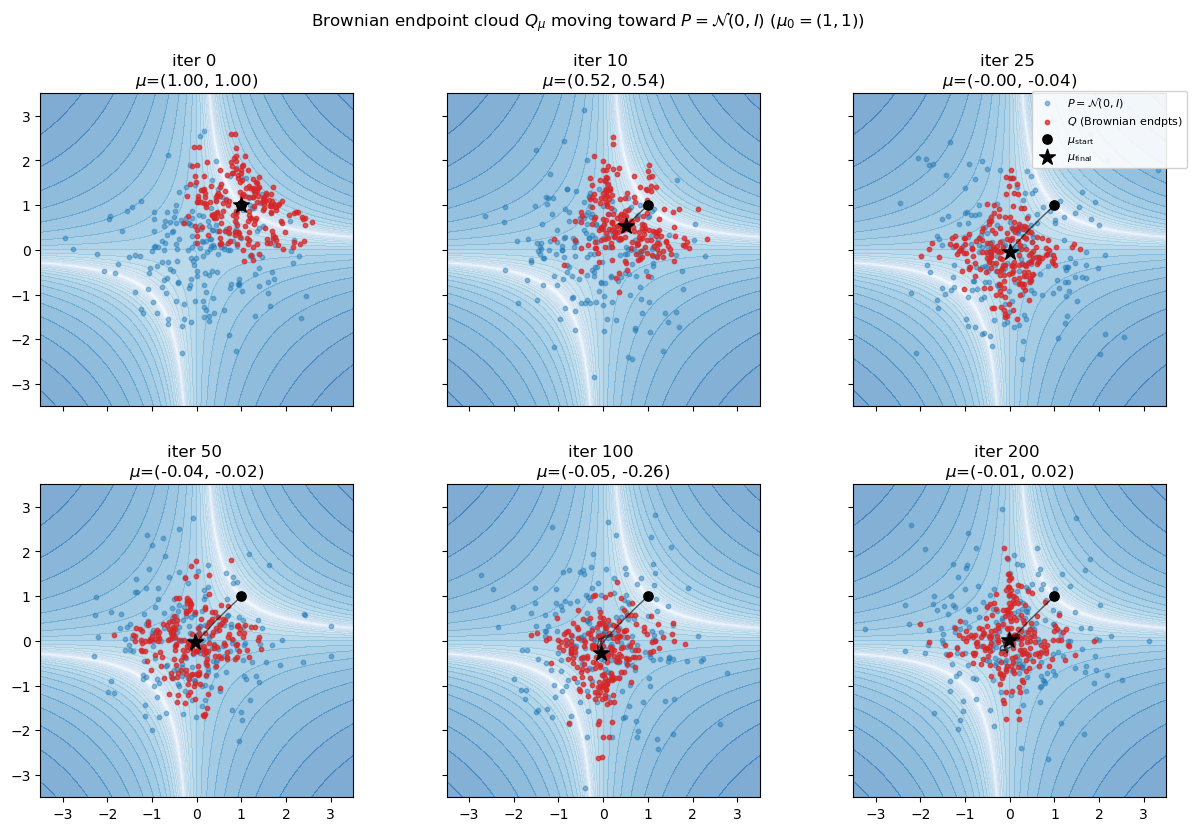

In [13]:
iters = sorted(snapshots_kl.keys())

ncols = 3
nrows = int(np.ceil(len(iters) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 4.2 * nrows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

xs = np.linspace(-3.5, 3.5, 400)
xs_nz = xs[np.abs(xs) > 0.3]

for ax, it in zip(axes, iters):

    snap = snapshots_kl[it]

    ax.contourf(
        GX, GY, LOG_LOSS,
        levels=25,
        cmap="Blues",
        alpha=0.55
    )

    # ax.plot(
    #     xs_nz,
    #     1.0 / xs_nz,
    #     color="orange",
    #     lw=1.0,
    #     ls="--"
    # )

    ax.scatter(
        snap["X_p"][:, 0],
        snap["X_p"][:, 1],
        s=10,
        alpha=0.45,
        color="tab:blue",
        label=r"$P=\mathcal{N}(0,I)$"
    )

    ax.scatter(
        snap["X_q"][:, 0],
        snap["X_q"][:, 1],
        s=10,
        alpha=0.75,
        color="tab:red",
        label=r"$Q$ (Brownian endpts)"
    )

    mp = mu_hist_snap_kl[: it + 1]

    ax.plot(
        mp[:, 0],
        mp[:, 1],
        color="black",
        lw=1.0,
        alpha=0.6
    )

    # starting mu
    ax.scatter(
        [mp[0, 0]],
        [mp[0, 1]],
        color="black",
        marker="o",
        s=45,
        zorder=5,
        label=r"$\mu_{\mathrm{start}}$"
    )

    # current/final mu
    ax.scatter(
        [snap["mu"][0]],
        [snap["mu"][1]],
        color="black",
        marker="*",
        s=140,
        zorder=5,
        label=r"$\mu_{\mathrm{final}}$"
    )

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)

    ax.set_aspect("equal")

    ax.set_title(
        rf"iter {it} "
        f"\n$\\mu$=({snap['mu'][0]:.2f}, {snap['mu'][1]:.2f})"
    )

for ax in axes[len(iters):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.89),
    fontsize=8,
    framealpha=0.9
)

fig.suptitle(
    rf"Brownian endpoint cloud $Q_\mu$ moving toward "
    rf"$P=\mathcal{{N}}(0,I)$ ($\mu_0=(1,1)$)",
    fontsize=12,
)

fig.tight_layout()

fig.subplots_adjust(
    top=0.88,
    hspace=0.25
)

plt.show()